# 🧠 Handwritten Digit Recognition using Deep Neural Networks (MNIST)

## Introduction

This project implements a **Deep Neural Network (DNN)** to classify handwritten digits (0–9) using the **MNIST dataset**. The objective of this project is not only to achieve high prediction accuracy but also to understand the complete machine learning workflow through experimentation and analysis.

Throughout this notebook, multiple neural network architectures are developed and compared to study the effects of **model complexity**, **overfitting**, and **L2 regularization**. A systematic hyperparameter search is performed to determine the optimal regularization strength (λ), and each model is evaluated using **classification error** on the training, cross-validation, and test sets.

In addition to model training and evaluation, this project includes several visualizations such as loss curves, lambda tuning results, misclassified handwritten digits, and raw logits produced by the neural network. Finally, an interactive prediction system is built that allows users to draw their own handwritten digit in Microsoft Paint and obtain the model's prediction, confidence scores, and logit visualization.

This notebook was developed as a learning project to gain a deeper understanding of neural networks while implementing and analyzing each component step by step rather than treating the model as a black box.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import pandas as pd
import struct
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam


In [2]:
                                                            # Extracting features for our Train Set 
with open("train-images.idx3-ubyte", "rb") as file:
    magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
    X_train = file.read()
print("magic id of the file is : ",magic)
print("Size of our test data set is : ",size)
print("Total no of rows in the data are :",rows)
print("Total no of columns in the data are : ",cols)


X_train = np.frombuffer(X_train, dtype=np.uint8)
print("Shape of our data set before reshape : ",X_train.shape)
X_train=X_train.reshape(60000,784)
print("Shape of our data set after reshape : ",X_train.shape)
print(X_train[:5])

magic id of the file is :  2051
Size of our test data set is :  60000
Total no of rows in the data are : 28
Total no of columns in the data are :  28
Shape of our data set before reshape :  (47040000,)
Shape of our data set after reshape :  (60000, 784)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [3]:
                                                            # Extracting Targets for our Train Set 
with open("train-labels.idx1-ubyte", "rb") as file:
    magic, size  = struct.unpack(">II", file.read(8))
    Y_train = file.read()
print("magic id of the file is : ",magic)
print("Size of our test data set is : ",size)


Y_train = np.frombuffer(Y_train, dtype=np.uint8)
print("Shape of our data set before reshape : ",Y_train.shape)

print(Y_train[:5])

magic id of the file is :  2049
Size of our test data set is :  60000
Shape of our data set before reshape :  (60000,)
[5 0 4 1 9]


In [4]:
                                                            # Extracting features for our Test Set 
with open("t10k-images.idx3-ubyte", "rb") as file:
    magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
    X_test = file.read()
print("magic id of the file is : ",magic)
print("Size of our test data set is : ",size)
print("Total no of rows in the data are :",rows)
print("Total no of columns in the data are : ",cols)


X_test = np.frombuffer(X_test, dtype=np.uint8)
print("Shape of our data set before reshape : ",X_test.shape)
X_test=X_test.reshape(10000,784)
print("Shape of our data set after reshape : ",X_test.shape)
print(X_test[:5])

magic id of the file is :  2051
Size of our test data set is :  10000
Total no of rows in the data are : 28
Total no of columns in the data are :  28
Shape of our data set before reshape :  (7840000,)
Shape of our data set after reshape :  (10000, 784)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [5]:
                                                            # Extracting Targets for our Test Set 
with open("t10k-labels.idx1-ubyte", "rb") as file:
    magic, size  = struct.unpack(">II", file.read(8))
    Y_test = file.read()
print("magic id of the file is : ",magic)
print("Size of our test data set is : ",size)


Y_test = np.frombuffer(Y_test, dtype=np.uint8)
print("Shape of our data set before reshape : ",Y_test.shape)

print(Y_test[:5])

magic id of the file is :  2049
Size of our test data set is :  10000
Shape of our data set before reshape :  (10000,)
[7 2 1 0 4]


In [6]:
                                            # Extracting Cv set from our train set 

from sklearn.model_selection import train_test_split

X_train, X_cv, Y_train, Y_cv = train_test_split(X_train, Y_train, test_size=0.1666666666, random_state=1)

print(X_train.shape)
print(Y_train.shape)
print(X_cv.shape)
print(Y_cv.shape)

(50000, 784)
(50000,)
(10000, 784)
(10000,)


In [7]:
print(X_train.shape)
print(Y_train.shape)
print(X_cv.shape)
print(Y_cv.shape)
print(X_test.shape)
print(Y_test.shape)

(50000, 784)
(50000,)
(10000, 784)
(10000,)
(10000, 784)
(10000,)


In [8]:
print(X_train.max())
print(X_train.min())

print(np.unique(Y_train))

print(X_train.dtype)
print(Y_train.dtype)

255
0
[0 1 2 3 4 5 6 7 8 9]
uint8
uint8


In [9]:
                                                # Normalizing the data so it easier and faster to process the data 

X_train = X_train.astype(np.float32) / 255.0
X_cv    = X_cv.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0



In [10]:
                                                # Defining our function, which will calculate the error in our model


# Since this is a multiclass classification problem (digits 0-9),
# Mean Squared Error (MSE) is not an appropriate evaluation metric.
# We will use classification error (or accuracy) to measure our model's performance.


def class_err(Y,Yhat):
    # Y is our target value of the dataset
    # Yhat is our prediction made by the model

    m=len(Yhat)
    incorrect=0
    for i in range(m):
        if Y[i] != Yhat[i]:
            incorrect += 1 
    errr = incorrect/m 

    return errr



**We will be building two neural networks; one will be a complex one with many neurons, and the other will be much simpler with fewer neurons to     analyse the difference between them and see which one is better**  


In [11]:
                                                                    # COMPLEX MODEL 



import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.random.set_seed(6969)
model_cmplx = Sequential(
    [
        Dense(units=250,activation="relu"),
        Dense(units=100,activation="relu"),
        Dense(units=10,activation="linear"),
        
    ], name= "Complex"
)
model_cmplx.compile(
     
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001),
        
)


In [ ]:
                                                                    # training the mmodel_cmplx

model_cmplx.fit(
    X_train,Y_train,
    epochs=20,
    validation_data=(X_cv, Y_cv)
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2247 - val_loss: 0.1153
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0886 - val_loss: 0.0938
Epoch 3/20
 305/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0674

**As you can see, the training loss did not decrease much, but the real elephant in the room is the validation (CV) loss. It kept increasing with    every epoch, which clearly indicates that the model is overfitting. The model is trying too hard to memorise the training data instead of          learning patterns that generalise well to unseen data.**

In [ ]:
# Let's try a simpler model this time with fewer neurons in each layer 

tf.random.set_seed(6969)
model_smple = Sequential(
    [
        Dense(units=100,activation="relu"),
        Dense(units=35,activation="relu"),
        Dense(units=10,activation="linear"),
        
    ], name= "Simple"
)
model_smple.compile(
     
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001),
        
)



In [ ]:
                                                          # training the simpler model

model_smple.fit(
    X_train,Y_train,
    epochs=20,
    validation_data=(X_cv, Y_cv)
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2840 - val_loss: 0.1585
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1234 - val_loss: 0.1130
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0842 - val_loss: 0.0978
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0621 - val_loss: 0.0960
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0468 - val_loss: 0.0973
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0368 - val_loss: 0.1058
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0303 - val_loss: 0.1063
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0246 - val_loss: 0.1067
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0212 - val_loss: 0.1119
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0184 - val_loss: 0.1279
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0183 - val_loss: 0.1337
Epoch 12/20
1563/1563 ━━━━━━━

**As you can see, the validation (CV) loss decreased. Although the improvement is not very large, it clearly shows that using a simpler neural network can help reduce overfitting by limiting the model's ability to memorize the training data**



**At this point, I'd like to share a valuable insight from my instructor, Andrew Ng:**

**"Having a larger or more complex neural network is usually not the problem. The real challenge is preventing it from overfitting, and proper regularization allows us to take advantage of larger models while maintaining good generalization."**

In [ ]:
# Now let's again return to our complex model but now with proper regularisation 

                                                         # Regularised COMPLEX MODEL 



tf.random.set_seed(6969)
model_cmplx_reg = Sequential(
    [
        Dense(units=250,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.00001)),
        Dense(units=100,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.00001)),
        Dense(units=10,activation="linear"),
        
    ], name= "Regularisedcomplex"
)
model_cmplx_reg.compile(
     
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001),
        
)


In [ ]:
model_cmplx_reg.fit(
    X_train,Y_train,
    epochs=20,
    validation_data=(X_cv, Y_cv)
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2342 - val_loss: 0.1227
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0977 - val_loss: 0.1044
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0673 - val_loss: 0.1124
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0533 - val_loss: 0.1357
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0464 - val_loss: 0.1149
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0390 - val_loss: 0.1306
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0382 - val_loss: 0.1454
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0380 - val_loss: 0.1354
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0347 - val_loss: 0.1330
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0345 - val_loss: 0.1449
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0343 - val_loss: 0.1340
Epoch 12/20
1563/1563 ━━━━━━

In [ ]:
model_cmplx_reg.summary()

Model: "Regularisedcomplex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 250)            │       196,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,082 (2.54 MB)

 Trainable params: 222,360 (868.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,722 (1.70 MB)

In [ ]:
# Now let's compare our 3 models based on classification error. First, we have to extract our predictions 
# of all 3 models, which will be fed to the classification error calculation function  

logits_complx_cv = model_cmplx.predict(X_cv)  
logits_simple_cv = model_smple.predict(X_cv)                      # logits from the cv data 
logits_complax_reg_cv = model_cmplx_reg.predict(X_cv)

logits_complx_train = model_cmplx.predict(X_train)
logits_simple_train = model_smple.predict(X_train)                   # logits from the Training data 
logits_complax_reg_train = model_cmplx_reg.predict(X_train)

# Now converting the logits into predicted digits 

Y_pred_complax_cv = np.argmax(logits_complx_cv, axis=1)
Y_pred_simple_cv = np.argmax(logits_simple_cv, axis=1)               # Predictions from the models trained on the CV data 
Y_pred_complax_reg_cv = np.argmax(logits_complax_reg_cv, axis=1)


Y_pred_complax_train = np.argmax(logits_complx_train, axis=1)
Y_pred_simple_train = np.argmax(logits_simple_train, axis=1)               # Predictions from the models trained on the training  data 
Y_pred_complax_reg_train = np.argmax(logits_complax_reg_train, axis=1)





313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 958us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
# Now let's calculate the classification error for each model and compare them 

cls_err_complx_cv = class_err(Y_cv,Y_pred_complax_cv)
cls_err_simple_cv = class_err(Y_cv,Y_pred_simple_cv)
cls_err_complx_reg_cv = class_err(Y_cv,Y_pred_complax_reg_cv)

cls_err_complx_train = class_err(Y_train,Y_pred_complax_train)
cls_err_simple_train = class_err(Y_train,Y_pred_simple_train)
cls_err_complx_reg_train = class_err(Y_train,Y_pred_complax_reg_train)

print("Classification errors of our complex modle are : \n","Train error is : ",cls_err_complx_train,"\n CV error is : ",cls_err_complx_cv)
print("Classification errors of our simple modle are : \n","Train error is : ",cls_err_simple_train,"\n CV error is : ",cls_err_simple_cv)
print("Classification errors of our regularised complex modle are : \n","Train error is : ",cls_err_complx_reg_train,"\n CV error is : ",cls_err_complx_reg_cv)

Classification errors of our complex modle are : 
 Train error is :  0.00294 
 CV error is :  0.0214
Classification errors of our simple modle are : 
 Train error is :  0.00704 
 CV error is :  0.0256
Classification errors of our regularised complex modle are : 
 Train error is :  0.00622 
 CV error is :  0.0251


**As we know, the best way to evaluate our models is by comparing their validation (CV) error, since it reflects how well the model generalizes to   unseen data. Based on the results above, our regularized complex model achieves the lowest CV error and therefore performs the best among the      three models. However, we can further improve this model by finding the optimal value of the regularization constant (λ). To do this, we will      train the same model using different values of λ and compare their CV errors. The value of λ that produces the lowest CV error will be             considered the optimal regularization strength for our model.**

In [ ]:
lambdas = [ 
    0.0002,
    0.0003,
    0.0004,
    0.0005,
    0.0006,
    0.0007,
    0.0001,
    0.00001,
    0.000001]


result={}

for lambda_current in (lambdas):
    
    print("Working on lambda = ",lambda_current)
    tf.random.set_seed(6969)
    model_= Sequential(
        [
            Dense(units=250,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(lambda_current)),
            Dense(units=100,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(lambda_current)),
            Dense(units=10,activation="linear"),
        
        ], name= "Regularisedcomplex"
    )
    model_  .compile(
     
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.001),
        
    )

    model_.fit(
    X_train,Y_train,
    epochs=10,
    
    )
    
    logits_ = model_.predict(X_cv)
    Y_pred_ = np.argmax(logits_, axis=1)

    classsss_error = class_err(Y_cv,Y_pred_)

    result[lambda_current]= classsss_error

    print("Testing for lambda = ",lambda_current,"is done ! ")    

Working on lambda =  0.0002
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3117
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1814
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1517
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.1371
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1250
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1192
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1114
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1058
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0982
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0988
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing for lambda =  0.0002 is done ! 
Working on lambda =  0.0003
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.3418
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.2029
Epoch 3/10
1563/1563 ━━

In [ ]:
for key, value in result.items():
    print("Lambda=",key,"  The classification error is  ",value)

Lambda= 0.0002   The classification error is   0.0336
Lambda= 0.0003   The classification error is   0.0267
Lambda= 0.0004   The classification error is   0.0249
Lambda= 0.0005   The classification error is   0.0276
Lambda= 0.0006   The classification error is   0.0296
Lambda= 0.0007   The classification error is   0.0299
Lambda= 0.0001   The classification error is   0.0239
Lambda= 1e-05   The classification error is   0.0249
Lambda= 1e-06   The classification error is   0.0246


In [ ]:
best_lambda = min(result, key=result.get)

print("Best lambda :", best_lambda)
print("Lowest CV Error :", result[best_lambda])

Best lambda : 0.0001
Lowest CV Error : 0.0239


## Top 3 Lambda Values After Initial Search (10 Epochs)

| Rank | Lambda (λ) | CV Classification Error |
|:---:|:----------:|:----------------------:|
| 🥇 1 | 0.0001 | 0.0239 |
| 🥈 2 | 0.000001 | 0.0246 |
| 🥉 3 | 0.00001 | 0.0249 |

In [ ]:
# Now lets rerun the test for these three values 

lambdas = [ 
    0.0001,
    0.00001,
    0.000001]




result_2nd={}

for lambda_current in (lambdas):
    
    print("Working on lambda = ",lambda_current)
    tf.random.set_seed(6969)
    model_= Sequential(
        [
            Dense(units=250,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(lambda_current)),
            Dense(units=100,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(lambda_current)),
            Dense(units=10,activation="linear"),
        
        ], name= "Regularisedcomplex"
    )
    model_  .compile(
     
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.001),
        
    )

    model_.fit(
    X_train,Y_train,
    epochs=30,
    
    )
    
    logits_ = model_.predict(X_cv)
    Y_pred_ = np.argmax(logits_, axis=1)

    classsss_error = class_err(Y_cv,Y_pred_)


    result[lambda_current]= classsss_error

    print("Testing for lambda = ",lambda_current,"is done ! ")    

Working on lambda =  0.0001
Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2731
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1501
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1243
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1097
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0994
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0957
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0925
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0906
Epoch 9/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0835
Epoch 10/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0832
Epoch 11/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0798
Epoch 12/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0781
Epoch 13/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0751
Epoch 14/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0773
E

# Now we have found the optimal value of lambda we can now train our final model on that value with the training data instead of cv set 

In [ ]:
# Now there is no use of our cv set so we can now merge cv and train set and train our final model on 60k immages 

X_final = np.concatenate((X_train, X_cv), axis=0)
Y_final = np.concatenate((Y_train, Y_cv), axis=0)

print(X_final.shape)
print(Y_final.shape)

(60000, 784)
(60000,)


In [ ]:

# Training Our final model 


tf.random.set_seed(6969)
model_cmplx_reg_final = Sequential(
    [
        Dense(units=250,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.00001)),
        Dense(units=100,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.00001)),
        Dense(units=10,activation="linear"),
        
    ], name= "Regularisedcomplex"
)
model_cmplx_reg_final.compile(
     
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=["accuracy"]
        
)

history=model_cmplx_reg_final.fit(
    X_final,Y_final,
    epochs=30,

    
    )

logits_ = model_cmplx_reg_final.predict(X_final)
Y_pred_train_final = np.argmax(logits_, axis=1)

classsss_error_train_final = class_err(Y_final,Y_pred_train_final)

print("The classification error for our CV data was  : 0.0198 \n The classification error for training data is : ",classsss_error_train_final)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9369 - loss: 0.2186
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9734 - loss: 0.0951
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0668
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9868 - loss: 0.0542
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9893 - loss: 0.0463
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0429
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9915 - loss: 0.0409
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0387
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9934 - loss: 0.0385
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9943 - loss: 0.0363
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9942 - loss: 0.0361
Epoch 12/30
1875/1875 ━━━━━━━━

In [ ]:
model_cmplx_reg_final.summary()

Model: "Regularisedcomplex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (32, 250)              │       196,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (32, 100)              │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (32, 10)               │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,082 (2.54 MB)

 Trainable params: 222,360 (868.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,722 (1.70 MB)

# Now lets see how does our final model will perform on our test set 

In [ ]:
logits_ = model_cmplx_reg_final.predict(X_test)
Y_pred_test = np.argmax(logits_, axis=1)

classsss_error_train_final_test = class_err(Y_test,Y_pred_test)

print("The classification error for our CV data was  : 0.0198 \n The classification error for training data is : ",classsss_error_train_final)
print("The classification errror for our Test data is : ",classsss_error_train_final_test )

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step
The classification error for our CV data was  : 0.0198 
 The classification error for training data is :  0.0017833333333333334
The classification errror for our Test data is :  0.0184


# Final result of our selected model

| Data Set  |  Classification Error |
|:----------:|:----------------------:|
| TRAINING SET | 0.00126 |
| CV SET | 0.00178  |
| TEST SET | 0.0184 |

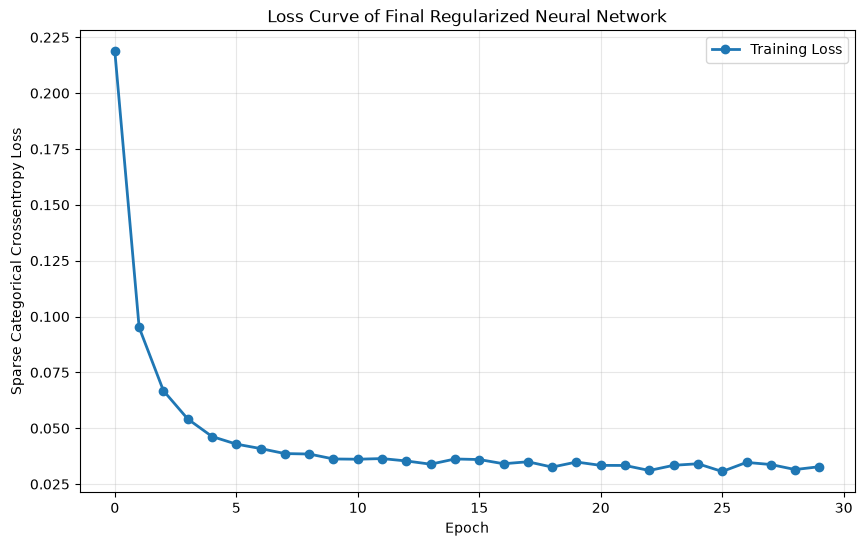

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history.history["loss"],
         linewidth=2,
         marker='o',
         label="Training Loss")


plt.title("Loss Curve of Final Regularized Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Crossentropy Loss")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Comparision Between different types of models

| Model  |  CV Error |  Train Error |
|:----------:|:----------------------:|:-----------------:|
| Complex Model  | 0.025  |  0.007 |
| Simpler Model | 0.033  |  0.009 |
| Regularised Complex Model | 0.022 | 0.005 |


In [ ]:
sorted_result = dict(sorted(result.items()))

lambdas = list(sorted_result.keys())
errors = list(sorted_result.values())

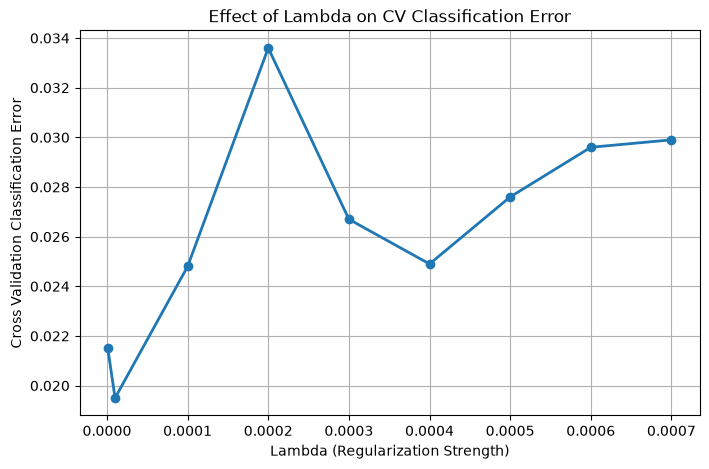

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(lambdas, errors, marker='o', linewidth=2)

plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Cross Validation Classification Error")
plt.title("Effect of Lambda on CV Classification Error")

plt.grid(True)
plt.show()

# Wrong predictions : 

In [ ]:
wrong_indices = np.where(Y_test != Y_pred_test)[0]

print(f"Total wrong predictions : {len(wrong_indices)} out of 10k images ")

Total wrong predictions : 184 out of 10k images 


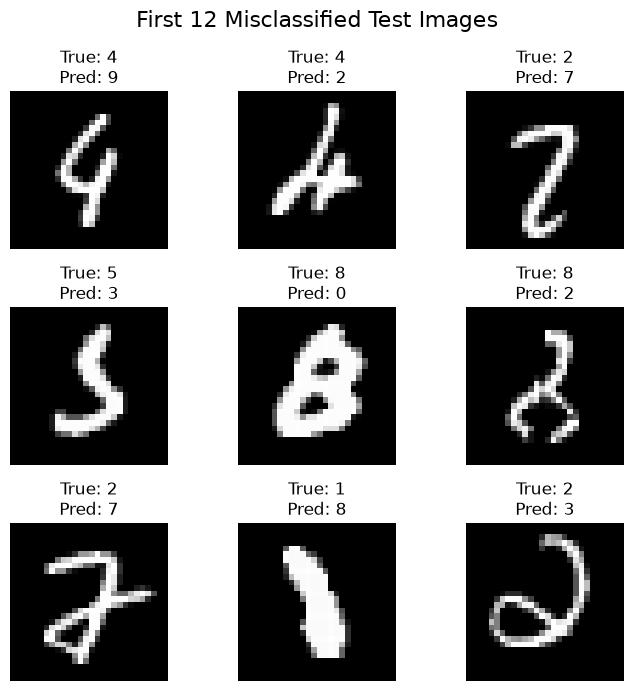

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

for i in range(9):

    idx = wrong_indices[i]

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[idx].reshape(28,28), cmap="gray")

    plt.title(f"True: {Y_test[idx]}\nPred: {Y_pred_test[idx]}")

    plt.axis("off")

plt.suptitle("First 12 Misclassified Test Images", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
def softmax(prediction_final_logits):

    new_logits = prediction_final_logits - np.max(prediction_final_logits)

    m=prediction_final_logits.shape[1]
    prob_array = np.zeros(m)
    logits_sum=0
    logits_exp=np.zeros(m)
    for i in range(m):

        exp_ = np.exp(new_logits[0,i])
        logits_exp[i] = exp_

        logits_sum += exp_

    for i in range(m):
        prob_array[i] = logits_exp[i]/logits_sum

    

    return prob_array 



    

In [ ]:
def show_bargraph(prediction_final_logits):

    digits = np.arange(10)

    plt.figure(figsize=(8,5))
    plt.bar(digits, prediction_final_logits.flatten())

    plt.xlabel("Digit")
    plt.ylabel("Logit")
    plt.title("Raw Logits Produced by the Neural Network")
    plt.xticks(digits)

    # Highlight the predicted digit
    pred = np.argmax(prediction_final_logits)

    plt.bar(pred, prediction_final_logits[0, pred])

    plt.grid(axis="y")
    plt.show()

In [ ]:
def show_prob (probabilities):
    m = len(probabilities)
    for i in range(m):
        print("Confidence for the digit ",i," is ~ ",probabilities[i]*100,"%")



# Interactive Handwritten Digit Prediction

Follow these steps to test the trained model with your own handwritten digit:

1. Open **Draw_here.png** in Microsoft Paint.
2. The canvas is **28 × 28 pixels**, the same size as images in the MNIST dataset.
3. Set the **brush size to 3 pixels**.
4. Draw a single digit (0–9) using a **white brush** on a **black background**.
5. Press **Ctrl + S** to save the image (do not change the filename).
6. Run the cells below to view:
   - ✅ Predicted digit
   - ✅ Confidence for each digit (0–9)
   - ✅ Raw logits produced by the neural network

In [ ]:
from PIL import Image
                                                                                            # Extracting pixels from the image 
img = Image.open("Draw_here.png").convert("L")                                              # .convert("L") to convert the image in to two colours black and white

x_input = np.array(img)

x_input = x_input.astype(np.float32) / 255.0
x_input = x_input.reshape(1,784)


prediction_final_logits = model_cmplx_reg_final.predict(x_input)                                
prediction_final = np.argmax(prediction_final_logits, axis=1)
print("The number you have drawn is : ",prediction_final)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The number you have drawn is :  [3]


In [ ]:
probabilities = softmax(prediction_final_logits)

print(probabilities)
print(prediction_final_logits)

[1.54653084e-26 1.37222142e-19 7.46418830e-11 1.00000000e+00
 6.61402043e-28 1.82569249e-15 1.22936953e-29 1.16454413e-20
 7.93014742e-14 2.75237009e-23]
[[-30.226135  -14.227625    5.886742   29.205061  -33.37813    -4.731757
  -37.363403  -16.694311   -0.9604581 -22.741934 ]]


# Below is the final cell run it to see the confidence on each digit and the graph 

Confidence for the digit  0  is ~  1.5465308357322879e-24 %
Confidence for the digit  1  is ~  1.372221421144611e-17 %
Confidence for the digit  2  is ~  7.464188295225327e-09 %
Confidence for the digit  3  is ~  100.0 %
Confidence for the digit  4  is ~  6.614020429812382e-26 %
Confidence for the digit  5  is ~  1.825692485171314e-13 %
Confidence for the digit  6  is ~  1.2293695326775361e-27 %
Confidence for the digit  7  is ~  1.164544125119506e-18 %
Confidence for the digit  8  is ~  7.93014742414555e-12 %
Confidence for the digit  9  is ~  2.752370092651578e-21 %


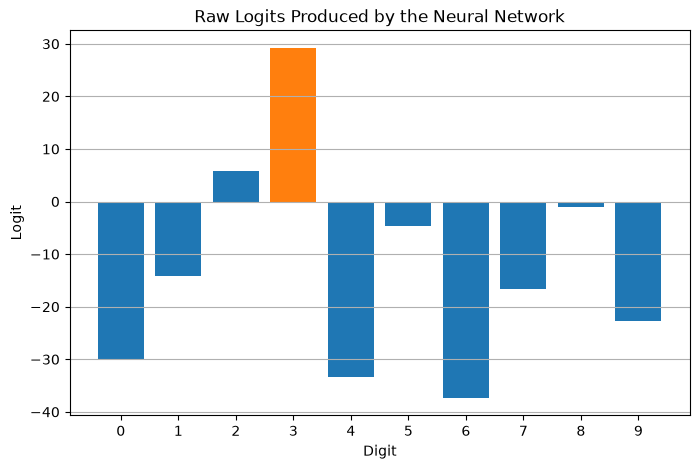

In [ ]:
show_prob(probabilities)
show_bargraph(prediction_final_logits)


# 🎯 Conclusion

In this project, a complete handwritten digit recognition system was successfully developed using Deep Neural Networks and the MNIST dataset.

Three different neural network architectures were implemented and compared:

- A complex model
- A simpler model
- A regularized complex model

The experiments demonstrated the effects of increasing model complexity, reducing overfitting through model simplification, and improving generalization using **L2 Regularization**. Different values of the regularization parameter (λ) were tested to identify the model with the lowest cross-validation classification error.

The final model achieved very similar **cross-validation** and **test classification errors**, indicating that it generalizes well to previously unseen handwritten digits.

Beyond model training, this project also included:
- Hyperparameter tuning
- Manual implementation of Softmax
- Classification error analysis
- Visualization of training and validation performance
- Analysis of misclassified images
- An interactive handwritten digit prediction system with confidence scores and logit visualization

Overall, this project provided valuable practical experience in designing, evaluating, debugging, and improving deep neural networks. More importantly, it reinforced the importance of understanding the reasoning behind each machine learning technique rather than simply applying existing models.

# Personal Note:
**This project was built while studying Deep Learning and Neural Networks. Rather than stopping after training a model, I explored different architectures, experimented with regularization, tuned hyperparameters, implemented Softmax manually, analyzed model errors, and built an interactive prediction system. Every experiment in this notebook contributed to a deeper understanding of how neural networks learn and generalize.**

In [ ]:
model_cmplx_reg_final.save("digit_model.keras")